# Build new inference index

This notebook shows how to build an Index compatible with `opr.inference.index`.


In [1]:
from pathlib import Path
from IPython.display import display

from torchvision import transforms as T
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn, Tensor
import open3d as o3d
#import MinkowskiEngine as ME
from PIL import Image


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
DIST_THRESH = 0.5
ANGLE_THRESH_DEG = 30

POINTCLOUD_QUANTIZATION_SIZE = 0.05


The example below is for SberRobotics Office dataset.

- `map1` - database, sampled with `DIST_THRESH` OR `ANGLE_THRESH_DEG`
- The rest of the maps will be the queries

In [3]:
root_data_dir = Path(
    "/mnt/external_usb_hdd/6YL/Datasets/archive/itlp_campus_indoor"
)
assert root_data_dir.exists(), f"Path {root_data_dir} does not exist"

DB_MAP_DIR = root_data_dir / "00_2023-10-25-night" / "floor_2"
assert DB_MAP_DIR.exists(), f"Path {DB_MAP_DIR} does not exist"


In [4]:
!ls -l $DB_MAP_DIR

total 144
drwxrwxr-x 2 kartashov_ga kartashov_ga 16384 янв 29 00:20 back_cam
drwxrwxr-x 2 kartashov_ga kartashov_ga 16384 янв 29 00:20 front_cam
drwxrwxr-x 2 kartashov_ga kartashov_ga 16384 янв 29 00:20 lidar
drwxrwxr-x 4 kartashov_ga kartashov_ga  4096 янв 29 00:20 masks
-rw-rw-r-- 1 kartashov_ga kartashov_ga 54407 мар 21  2025 track.csv
-rw-rw-r-- 1 kartashov_ga kartashov_ga 33378 мар 21  2025 track_map.png


In [6]:
!head $DB_MAP_DIR/poses.csv

timestamp,front_cam_ts,back_cam_ts,lidar_ts,tx,ty,tz,qx,qy,qz,qw
1698264504041122048,1698264504002182709,1698264504047208484,1698264504047677052,0.9360016743102808,-0.0056183494319767,99.97860149508678,-0.002075912593359,0.0012795092579553,-0.0685098581723661,0.9976474591638902
1698264507070846464,1698264507119317501,1698264507057790564,1698264507073838801,1.9127602113790148,0.5575754218259086,100.05623565155999,-0.0024149292485379,0.0041819423084829,-0.0374064416847546,0.9992884656573088
1698264508581344000,1698264508585594131,1698264508578256338,1698264508589850480,2.8301377675046844,0.2397384029464125,100.06522866460872,-0.0033749757925095,-0.0085756257723864,-0.4758351378643451,0.8794862078251322
1698264509993314304,1698264510033376489,1698264510019705506,1698264509997810962,3.1503588049980285,-0.7123755200815263,100.12628008912988,0.0009558810521864,-0.0188578832945311,-0.7079186675964818,0.7060415190323341
1698264511203823360,1698264511217856467,1698264511206572579,16982645112064

## load poses.csv

In [15]:
def load_trajectory_df(traj_path, sep=","):
    traj_df = pd.read_table(
        traj_path, header=1, sep=sep,
        names=["timestamp", "front_cam_ts", "back_cam_ts", "lidar_ts", "x", "y", "z", "qx", "qy", "qz", "qw"],
        comment='#'
    )
    print(f"Loaded frames with {len(traj_df)} entries.")
    return traj_df

In [16]:
db_map_df = load_trajectory_df(DB_MAP_DIR / "poses.csv")
display(db_map_df.head())
display(db_map_df.tail())

Loaded frames with 254 entries.


,timestamp,front_cam_ts,back_cam_ts,lidar_ts,x,y,z,qx,qy,qz,qw
0,1698264507070846464,1698264507119317501,1698264507057790564,1698264507073838801,1.912760,0.557575,100.056236,-0.002415,0.004182,-0.037406,0.999288
1,1698264508581344000,1698264508585594131,1698264508578256338,1698264508589850480,2.830138,0.239738,100.065229,-0.003375,-0.008576,-0.475835,0.879486
2,1698264509993314304,1698264510033376489,1698264510019705506,1698264509997810962,3.150359,-0.712376,100.126280,0.000956,-0.018858,-0.707919,0.706042
3,1698264511203823360,1698264511217856467,1698264511206572579,1698264511206429225,3.112751,-1.740502,100.169964,0.008021,-0.017280,-0.785810,0.618174
4,1698264512616763648,1698264512650593770,1698264512584227504,1698264512620263769,2.697550,-2.707313,100.225336,0.019091,-0.018710,-0.930466,0.365403


,timestamp,front_cam_ts,back_cam_ts,lidar_ts,x,y,z,qx,qy,qz,qw
249,1698264849718639616,1698264849676965759,1698264849689958331,1698264849722924313,2.660992,2.294300,99.866778,-0.024562,0.022925,0.607234,-0.793813
250,1698264851028064512,1698264850990813971,1698264850985596943,1698264851032721570,2.853010,1.271028,99.926578,-0.018994,0.013818,0.769123,-0.638669
251,1698264852642632704,1698264852640794484,1698264852612610043,1698264852646716773,2.486120,0.393792,99.996949,-0.022611,0.017190,0.975104,-0.219922
252,1698264854963774720,1698264854908024867,1698264854953993503,1698264854969959146,1.486615,0.207877,100.089107,-0.022693,0.022959,0.999041,0.029591
253,1698264858394072576,1698264858432181045,1698264858408129041,1698264858398401671,0.442454,0.300887,100.167926,-0.019875,0.017961,0.999511,0.016124


## Check images dir

In [17]:
images_dir = DB_MAP_DIR / "front_cam"
assert images_dir.exists(), f"Path {images_dir} does not exist"

num_files = len(list(images_dir.iterdir()))
print(f"Number of files: {num_files}")

# images_timestamps = DB_MAP_DIR / "zedx_front_left" / "image_timestamps.txt"

# images_timestamps = pd.read_csv(images_timestamps, header=None, sep=", ")
# images_timestamps = images_timestamps[1].tolist()
# images_timestamps = np.array([x / 1e9 for x in images_timestamps], dtype=np.float64)

# print(images_timestamps[:5])

# lidar_timestamps = db_map_df["timestamp"].to_numpy(dtype=np.float64)

# diffs_0 = np.abs(lidar_timestamps[:-2] - images_timestamps)
# diffs_1 = np.abs(lidar_timestamps[1:-1] - images_timestamps)
# diffs_2 = np.abs(lidar_timestamps[2:] - images_timestamps)

# print(diffs_0.mean(), diffs_0.max(), diffs_0.min(), np.median(diffs_0))
# print(diffs_1.mean(), diffs_1.max(), diffs_1.min(), np.median(diffs_1))
# print(diffs_2.mean(), diffs_2.max(), diffs_2.min(), np.median(diffs_2))

Number of files: 256


## cut poses by images len

In [18]:
if num_files < len(db_map_df):
    db_map_df = db_map_df.iloc[:num_files]

display(db_map_df.tail())


,timestamp,front_cam_ts,back_cam_ts,lidar_ts,x,y,z,qx,qy,qz,qw
249,1698264849718639616,1698264849676965759,1698264849689958331,1698264849722924313,2.660992,2.294300,99.866778,-0.024562,0.022925,0.607234,-0.793813
250,1698264851028064512,1698264850990813971,1698264850985596943,1698264851032721570,2.853010,1.271028,99.926578,-0.018994,0.013818,0.769123,-0.638669
251,1698264852642632704,1698264852640794484,1698264852612610043,1698264852646716773,2.486120,0.393792,99.996949,-0.022611,0.017190,0.975104,-0.219922
252,1698264854963774720,1698264854908024867,1698264854953993503,1698264854969959146,1.486615,0.207877,100.089107,-0.022693,0.022959,0.999041,0.029591
253,1698264858394072576,1698264858432181045,1698264858408129041,1698264858398401671,0.442454,0.300887,100.167926,-0.019875,0.017961,0.999511,0.016124


## filter poses

In [19]:
def filter_db_by_spatial_and_angular_thresholds(
    df: pd.DataFrame,
    dist_thresh: float,
    angle_thresh_deg: float,
    position_columns: list[str] = ["x", "y", "z"],
    quaternion_columns: list[str] = ["qx", "qy", "qz", "qw"],
    start_with_first: bool = True,
) -> pd.DataFrame:
    """Filter frames by spatial and angular thresholds.

    Samples frames sequentially from ``df``. A frame is selected if it is farther
    than ``dist_thresh`` from all currently selected frames. Otherwise (if it is
    spatially close), it is selected only if the angular distance to the closest
    selected frame exceeds ``angle_thresh_deg``.

    Args:
        df: DataFrame with at least the position and quaternion columns.
        dist_thresh: Minimum Euclidean distance (meters) to accept unconditionally.
        angle_thresh_deg: Angular distance threshold in degrees when spatially close.
        position_columns: Names of position columns in order [x, y, z].
        quaternion_columns: Names of quaternion columns in order [qx, qy, qz, qw].
        start_with_first: Whether to force-include the first frame to seed selection.

    Returns:
        A new DataFrame containing the sampled frames in their original order.
    """
    # Validate columns
    required_cols = position_columns + quaternion_columns
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    if len(df) == 0:
        return df.copy()

    positions = df[position_columns].to_numpy(dtype=float, copy=True)
    quaternions = df[quaternion_columns].to_numpy(dtype=float, copy=True)

    selected_indices: list[int] = []

    def _normalize_quaternion(q: np.ndarray) -> np.ndarray:
        """Return unit quaternion; if zero-norm, return input."""
        norm = np.linalg.norm(q)
        return q / norm if norm > 0 else q

    def _quaternion_angle_diff_deg(q1: np.ndarray, q2: np.ndarray) -> float:
        """Compute minimal angular difference between two quaternions in degrees."""
        q1n = _normalize_quaternion(q1)
        q2n = _normalize_quaternion(q2)
        dot = float(np.clip(np.abs(np.dot(q1n, q2n)), -1.0, 1.0))
        angle_rad = 2.0 * np.arccos(dot)
        return float(np.degrees(angle_rad))

    if start_with_first:
        selected_indices.append(0)

    selected_positions = (
        positions[selected_indices]
        if selected_indices
        else np.empty((0, positions.shape[1]), dtype=float)
    )
    selected_quaternions = (
        quaternions[selected_indices]
        if selected_indices
        else np.empty((0, quaternions.shape[1]), dtype=float)
    )

    start_i = 1 if start_with_first else 0
    for i in range(start_i, len(df)):
        pos_i = positions[i]
        quat_i = quaternions[i]

        if selected_positions.shape[0] == 0:
            selected_indices.append(i)
            selected_positions = np.vstack([selected_positions, pos_i])
            selected_quaternions = np.vstack([selected_quaternions, quat_i])
            continue

        dists = np.linalg.norm(selected_positions - pos_i, axis=1)
        nearest_sel_idx = int(np.argmin(dists))
        min_dist = float(dists[nearest_sel_idx])

        if min_dist > dist_thresh:
            should_select = True
        else:
            ang_deg = _quaternion_angle_diff_deg(quat_i, selected_quaternions[nearest_sel_idx])
            should_select = ang_deg > angle_thresh_deg

        if should_select:
            selected_indices.append(i)
            selected_positions = np.vstack([selected_positions, pos_i])
            selected_quaternions = np.vstack([selected_quaternions, quat_i])

    filtered_df = df.iloc[selected_indices]
    print(
        f"Selected {len(filtered_df)} / {len(df)} frames "
        f"({len(filtered_df) / max(1, len(df)):.1%})."
    )
    return filtered_df


In [32]:
filtered_df = filter_db_by_spatial_and_angular_thresholds(
    db_map_df,
    dist_thresh=DIST_THRESH,
    angle_thresh_deg=ANGLE_THRESH_DEG,
)
display(filtered_df.head())
display(filtered_df.tail())

Selected 254 / 254 frames (100.0%).


,timestamp,front_cam_ts,back_cam_ts,lidar_ts,x,y,z,qx,qy,qz,qw
0,1698264507070846464,1698264507119317501,1698264507057790564,1698264507073838801,1.912760,0.557575,100.056236,-0.002415,0.004182,-0.037406,0.999288
1,1698264508581344000,1698264508585594131,1698264508578256338,1698264508589850480,2.830138,0.239738,100.065229,-0.003375,-0.008576,-0.475835,0.879486
2,1698264509993314304,1698264510033376489,1698264510019705506,1698264509997810962,3.150359,-0.712376,100.126280,0.000956,-0.018858,-0.707919,0.706042
3,1698264511203823360,1698264511217856467,1698264511206572579,1698264511206429225,3.112751,-1.740502,100.169964,0.008021,-0.017280,-0.785810,0.618174
4,1698264512616763648,1698264512650593770,1698264512584227504,1698264512620263769,2.697550,-2.707313,100.225336,0.019091,-0.018710,-0.930466,0.365403


,timestamp,front_cam_ts,back_cam_ts,lidar_ts,x,y,z,qx,qy,qz,qw
249,1698264849718639616,1698264849676965759,1698264849689958331,1698264849722924313,2.660992,2.294300,99.866778,-0.024562,0.022925,0.607234,-0.793813
250,1698264851028064512,1698264850990813971,1698264850985596943,1698264851032721570,2.853010,1.271028,99.926578,-0.018994,0.013818,0.769123,-0.638669
251,1698264852642632704,1698264852640794484,1698264852612610043,1698264852646716773,2.486120,0.393792,99.996949,-0.022611,0.017190,0.975104,-0.219922
252,1698264854963774720,1698264854908024867,1698264854953993503,1698264854969959146,1.486615,0.207877,100.089107,-0.022693,0.022959,0.999041,0.029591
253,1698264858394072576,1698264858432181045,1698264858408129041,1698264858398401671,0.442454,0.300887,100.167926,-0.019875,0.017961,0.999511,0.016124


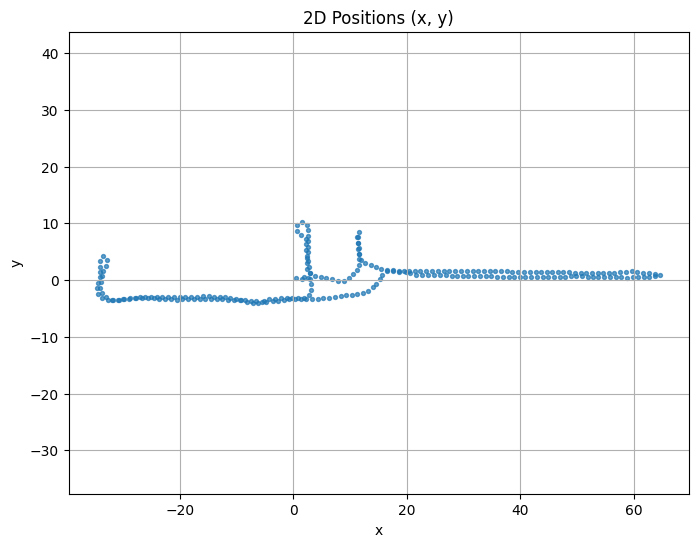

In [21]:
def plot_xy_positions(df):
    """Plot 2D x-y positions from a DataFrame."""
    plt.figure(figsize=(8, 6))
    plt.scatter(df["x"], df["y"], s=8, alpha=0.7)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("2D Positions (x, y)")
    plt.axis("equal")
    plt.grid(True)
    plt.show()

plot_xy_positions(filtered_df)


In [29]:
selected_indices = filtered_df.index.tolist()
print(f"selected {len(selected_indices)} indices, first 5: {selected_indices[:5]}")


selected 254 indices, first 5: [0, 1, 2, 3, 4]


## get paths for images files

In [50]:
selected_images = [images_dir / f"{i}.png" for i in filtered_df.iloc[selected_indices, 1]]
print(f"selected {len(selected_images)} images, first 5: {selected_images[:5]}")
selected_images_paths = [str(image.relative_to(DB_MAP_DIR)) for image in selected_images]
print(f"selected_images_paths: {selected_images_paths}")


selected 254 images, first 5: [PosixPath('/mnt/external_usb_hdd/6YL/Datasets/archive/itlp_campus_indoor/00_2023-10-25-night/floor_2/front_cam/1698264507119317501.png'), PosixPath('/mnt/external_usb_hdd/6YL/Datasets/archive/itlp_campus_indoor/00_2023-10-25-night/floor_2/front_cam/1698264508585594131.png'), PosixPath('/mnt/external_usb_hdd/6YL/Datasets/archive/itlp_campus_indoor/00_2023-10-25-night/floor_2/front_cam/1698264510033376489.png'), PosixPath('/mnt/external_usb_hdd/6YL/Datasets/archive/itlp_campus_indoor/00_2023-10-25-night/floor_2/front_cam/1698264511217856467.png'), PosixPath('/mnt/external_usb_hdd/6YL/Datasets/archive/itlp_campus_indoor/00_2023-10-25-night/floor_2/front_cam/1698264512650593770.png')]
selected_images_paths: ['front_cam/1698264507119317501.png', 'front_cam/1698264508585594131.png', 'front_cam/1698264510033376489.png', 'front_cam/1698264511217856467.png', 'front_cam/1698264512650593770.png', 'front_cam/1698264513898368094.png', 'front_cam/1698264515004160083.pn

## calculate descriptors for index

In [51]:
class MegaLocOPRModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = torch.hub.load("gmberton/MegaLoc", "get_trained_model")

    def forward(self, batch: dict[str, Tensor]) -> dict[str, Tensor]:
        key = next((k for k in batch if k.startswith("images_")), None)
        if key is None:
            raise KeyError("No key starting with 'images_' found in the batch.")
        images = batch[key]
        descriptor = self.model(images)
        output = {"final_descriptor": descriptor}
        return output


In [52]:
model = MegaLocOPRModel()
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Using cache found in /home/kartashov_ga/.cache/torch/hub/gmberton_MegaLoc_main
Using cache found in /home/kartashov_ga/.cache/torch/hub/facebookresearch_dinov2_main


MegaLocOPRModel(
  (model): MegaLocModel(
    (backbone): DINOv2(
      (model): DinoVisionTransformer(
        (patch_embed): PatchEmbed(
          (proj): Conv2d(3, 768, kernel_size=(14, 14), stride=(14, 14))
          (norm): Identity()
        )
        (blocks): ModuleList(
          (0-11): 12 x NestedTensorBlock(
            (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
            (attn): MemEffAttention(
              (qkv): Linear(in_features=768, out_features=2304, bias=True)
              (proj): Linear(in_features=768, out_features=768, bias=True)
              (proj_drop): Dropout(p=0.0, inplace=False)
            )
            (ls1): LayerScale()
            (drop_path1): Identity()
            (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
            (mlp): Mlp(
              (fc1): Linear(in_features=768, out_features=3072, bias=True)
              (act): GELU(approximate='none')
              (fc2): Linear(in_features=3072, out_featur

In [53]:
image_transform_fn = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    T.Resize([322, 322], antialias=True)
])

In [54]:
def read_image(image_filepath: str | Path) -> Tensor:
    image = Image.open(image_filepath)
    image = image_transform_fn(image)
    return image


def to_batch(image: Tensor) -> dict[str, Tensor]:
    return {"images_0": image.unsqueeze(0)}

In [55]:
descriptors = []
for image_path in selected_images_paths:
    image = read_image(DB_MAP_DIR / image_path)
    batch = to_batch(image)
    batch = {k: v.to(device) for k, v in batch.items()}
    with torch.no_grad():
        desc = model(batch)
    descriptors.append(desc["final_descriptor"].cpu().numpy())
descriptors = np.concatenate(descriptors, axis=0)
np.save(DB_MAP_DIR / "descriptors.npy", descriptors)

print(f"Descriptors saved to {DB_MAP_DIR / 'descriptors.npy'}")


Descriptors saved to /mnt/external_usb_hdd/6YL/Datasets/archive/itlp_campus_indoor/00_2023-10-25-night/floor_2/descriptors.npy


In [56]:
N, D = descriptors.shape
print(f"descriptors shape: {descriptors.shape}")

descriptors shape: (254, 8448)


## build FaissFlatIndex files

In [57]:
# Build minimal FAISS index files for the filtered database and load FaissFlatIndex
import json
from opr.inference.index import FaissFlatIndex

index_dir = DB_MAP_DIR

# Build meta.parquet with required columns; pointcloud_path omitted (treated as NaN)
poses = filtered_df[["x", "y", "z", "qx", "qy", "qz", "qw"]].to_numpy(dtype=float)
poses_list = [list(p) for p in poses]
meta = pd.DataFrame({
    "idx": filtered_df.index.to_numpy(dtype=np.int64),
    "pose": poses_list,
    "image_path": selected_images_paths,
})
meta.to_parquet(index_dir / "meta.parquet")

# Minimal schema.json
schema = {"version": "1", "dim": D, "metric": "l2", "created_at": "", "opr_version": ""}
(index_dir / "schema.json").write_text(json.dumps(schema))

# Load the index
index = FaissFlatIndex.load(index_dir)
print(f"Index created at {index_dir}")
print(f"Index size: {index.size()}, dim: {index.dim()} metric: {index.metric()}")


Index created at /mnt/external_usb_hdd/6YL/Datasets/archive/itlp_campus_indoor/00_2023-10-25-night/floor_2
Index size: 254, dim: 8448 metric: l2


# Sample PlaceRecognitionPipeline inference

In [ ]:
QUERY_MAP_DIR = root_data_dir / "map2" / "keyframe_map"
assert QUERY_MAP_DIR.exists(), f"Path {QUERY_MAP_DIR} does not exist"

image = read_image(QUERY_MAP_DIR / "zedx_front_left" / "rgb" / "000036.jpg")
sample_query_batch = to_batch(image)
sample_query_batch = {k: v.to(device) for k, v in sample_query_batch.items()}


In [ ]:
# Load index and run PlaceRecognitionPipeline
from opr.inference.index import FaissFlatIndex
from opr.inference.pipelines import PlaceRecognitionPipeline, SequencePlaceRecognitionPipeline

index = FaissFlatIndex.load(DB_MAP_DIR)
# pipeline = PlaceRecognitionPipeline(index=index, model=model, device="cuda")
pipeline = SequencePlaceRecognitionPipeline(index=index, model=model, device="cuda", max_window=26)

result = pipeline.infer(input_frame=sample_query_batch, k=5)
print(f"descriptor shape: {result.descriptor.shape}")
print(f"indices: {result.indices.tolist()}")
print(f"distances: {[float(x) for x in result.distances]}")
print(f"db_idx: {result.db_idx.tolist()}")
print(f"db_pose (first): {result.db_pose[0]}")

In [ ]:
from time import time

times = []
for i in range(300):
    image = read_image(QUERY_MAP_DIR / "zedx_front_left" / "rgb" / f"{i:06d}.jpg")
    sample_query_batch = to_batch(image)
    sample_query_batch = {k: v.to(device) for k, v in sample_query_batch.items()}
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    start = time()
    result = pipeline.infer(input_frame=sample_query_batch, k=5)
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    end = time()
    times.append(end - start)

print(f"mean time: {np.mean(times[30:])*1000:.2f} ms")